<h1 style="text-align: center;">Analysis of Global Earthquake Data</h1>


<p>
Earthquakes are among the most impactful natural phenomena, causing significant loss of life,
infrastructure damage, and economic disruption worldwide. Understanding how earthquake events
are distributed and how they evolve over time is essential for improving disaster preparedness
and scientific research.
</p>

<p>
This project analyzes a historical earthquake dataset provided by the National Oceanic and
Atmospheric Administration (NOAA). The dataset contains records of earthquake events spanning
several centuries and includes information such as the year of occurrence, geographic coordinates,
and reported earthquake magnitude.
</p>

<p>
Using Python and data analysis techniques learned in the course, several indicators are constructed
to explore earthquake behavior. These include grouping-based queries, data transformation through
normalization, trend analysis using moving averages, and clustering methods based on geographic
coordinates. The results are presented through an interactive dashboard developed using the Dash
framework.
</p>

<p>
The main objective of this project is to identify meaningful patterns in earthquake occurrence and
to demonstrate the application of data science methods on a real-world dataset.
</p>


### 1. Data Collection

1.1 Import libraries

In [35]:
import pandas as pd
import numpy as np


In this step, we import the Python libraries required for the project.
Pandas is used to load and manipulate tabular data, while NumPy provides numerical operations that are useful for data analysis and transformations.

1.2 Load the dataset

In [36]:
def load_data(file_path):
    """
    Reads the earthquake CSV file.
    Input: file_path (string) – path to the CSV file
    Output: pandas DataFrame
    """
    df = pd.read_csv(file_path)
    return df


This function loads the earthquake dataset from a CSV file and stores it in a Pandas DataFrame.
Encapsulating the loading process inside a function improves code organization, reusability, and readability, as required by the project instructions

1.3 Dataset overview

In [37]:
def dataset_overview(df):
    """
    Displays basic information about the dataset.
    Input: DataFrame
    Output: None
    """
    print("Number of rows and columns:", df.shape)
    print("\nData types of each column:\n")
    print(df.dtypes)


This function provides a general overview of the dataset.
It displays the number of rows and columns, as well as the data type of each attribute.
This step helps us understand the structure of the data and identify which variables are numerical, categorical, temporal, or spatial

1.4 Missing values per column

In [38]:
def missing_values(df):
    """
    Counts missing values for each column.
    Input: DataFrame
    Output: Series containing missing value counts
    """
    return df.isna().sum()


This function computes the number of missing values for each column in the dataset.
Identifying missing data is essential for understanding data quality, especially in historical datasets such as earthquake records that span thousands of years.

1.5 Statistical summary

In [39]:
def statistical_summary(df):
    """
    Generates descriptive statistics for numerical columns.
    Input: DataFrame
    Output: DataFrame with summary statistics
    """
    return df.describe()


This function generates descriptive statistics (mean, minimum, maximum, quartiles, etc.) for all numerical variables in the dataset.
These statistics provide insight into the distribution and scale of earthquake-related attributes such as magnitude, depth, latitude, and longitude.

1.6 Call Step 1 functions

In [40]:
df = load_data("earthquakes.csv")
dataset_overview(df)
missing_values(df)
statistical_summary(df)


Number of rows and columns: (4424, 38)

Data types of each column:

Year                                  float64
Mo                                    float64
Dy                                    float64
Hr                                    float64
Mn                                    float64
Sec                                   float64
Tsu                                   float64
Vol                                   float64
Location Name                          object
Latitude                              float64
Longitude                             float64
Focal Depth (km)                      float64
Mag                                   float64
MMI Int                               float64
Deaths                                float64
Death Description                     float64
Missing                               float64
Missing Description                   float64
Injuries                              float64
Injuries Description                  float64
Damage ($Mil

,Year,Mo,Dy,Hr,Mn,Sec,Tsu,Vol,Latitude,Longitude,...,Total Missing,Total Missing Description,Total Injuries,Total Injuries Description,Total Damage ($Mil),Total Damage Description,Total Houses Destroyed,Total Houses Destroyed Description,Total Houses Damaged,Total Houses Damaged Description
count,4424.000000,4330.000000,4280.000000,3665.000000,3581.000000,3437.000000,1390.000000,36.000000,4424.000000,4424.000000,...,25.00000,26.000000,1253.000000,1432.000000,456.000000,2876.000000,7.760000e+02,1549.000000,4.260000e+02,787.000000
mean,1887.339286,6.525635,15.772430,11.310232,28.940799,24.423916,2294.876259,3769.250000,20.611729,46.949802,...,1910.68000,1.807692,2390.756584,1.942737,1892.405592,2.167942,1.899685e+04,2.684312,5.913080e+04,2.473952
std,283.896376,3.443356,8.773091,7.053683,17.272006,19.187007,1599.876217,2202.337529,23.830736,90.578248,...,8667.79685,1.059027,27489.599557,1.078765,12469.563604,1.051688,2.001101e+05,1.074916,1.017700e+06,1.135936
min,-2150.000000,1.000000,1.000000,0.000000,0.000000,0.000000,9.000000,43.000000,-62.877000,-179.984000,...,1.00000,1.000000,1.000000,1.000000,0.010000,1.000000,1.000000e+00,1.000000,1.000000e+00,1.000000
25%,1906.000000,4.000000,8.000000,5.000000,14.000000,5.900000,1277.500000,2205.000000,3.415750,1.500000,...,5.00000,1.000000,10.000000,1.000000,4.875000,1.000000,6.000000e+01,2.000000,9.000000e+01,1.000000
50%,1967.000000,7.000000,16.000000,11.000000,29.000000,23.300000,1965.500000,4102.500000,29.581500,69.267500,...,21.00000,1.000000,40.000000,1.000000,30.000000,2.000000,5.000000e+02,3.000000,6.735000e+02,3.000000
75%,2002.000000,9.000000,23.000000,18.000000,44.000000,41.000000,3029.500000,5124.000000,38.320750,121.373000,...,138.00000,3.000000,200.000000,3.000000,292.500000,3.000000,3.618250e+03,4.000000,3.000000e+03,3.000000
max,2020.000000,12.000000,31.000000,23.000000,59.000000,59.900000,5760.000000,7444.000000,73.122000,180.000000,...,43476.00000,4.000000,799000.000000,4.000000,220085.456000,4.000000,5.360000e+06,4.000000,2.100000e+07,4.000000


In this step, all data collection and exploration functions are executed.
The dataset is loaded, its structure is analyzed, missing values are identified, and descriptive statistics are computed.
This completes the Data Collection phase of the project.

### STEP 2 – INDICATOR 1
Grouping Query: Number of earthquakes per century

In [41]:
def earthquakes_per_century(df):
    """
    Groups earthquakes by century and counts how many occurred in each century.

    Input:
        df (DataFrame): Earthquake dataset

    Output:
        DataFrame with two columns:
        - Century
        - Count of earthquakes
    """
    df = df.copy()

    # Convert year to century
    df['Century'] = (df['Year'] // 100) * 100

    # Group by century and count earthquakes
    result = df.groupby('Century').size().reset_index(name='Count')

    return result


### 2.Techniques Applied
### 2.1 Indicator 1 – Earthquakes per Century

This indicator groups earthquake events by century and counts how many earthquakes occurred in each one.
The century is calculated from the year by applying an integer division by 100.

This grouping query allows us to observe long-term historical trends in earthquake occurrence.
By analyzing the number of earthquakes per century, we can identify periods with higher seismic activity and better understand how earthquake recording has evolved over time.

In [42]:
df_century = earthquakes_per_century(df)
df_century.head()




,Century,Count
0,-2200.0,1
1,-2000.0,1
2,-1300.0,1
3,-1100.0,1
4,-500.0,2


The function is executed using the earthquake dataset, producing a table that shows the number of recorded earthquakes per century.
This result will later be used in the visualization dashboard

### 2.2 INDICATOR 2
Data Transformation – Min-Max Normalization of Earthquake Magnitude



In [43]:
def normalize_magnitude(df):
    """
    Applies Min-Max normalization to the earthquake magnitude.

    Input:
        df (DataFrame): Earthquake dataset

    Output:
        DataFrame with original and normalized magnitude values
    """
    df = df.copy()

    # Min and max of the magnitude column
    min_mag = df['Mag'].min()
    max_mag = df['Mag'].max()

    # Min-Max normalization
    df['Mag_Normalized'] = (df['Mag'] - min_mag) / (max_mag - min_mag)

    return df[['Mag', 'Mag_Normalized']]


Normalization of Earthquake Magnitude

In the NOAA earthquake dataset, the earthquake magnitude is stored in the attribute Mag, which represents the reported magnitude of each seismic event.
Min-Max normalization is applied to this attribute in order to rescale magnitude values between 0 and 1 using the formula

$x' = \frac{x - \min(x)}{\max(x) - \min(x)}$

This transformation improves comparability between events and prepares the data for further analysis such as clustering or visualization.

In [44]:
df_normalized = normalize_magnitude(df)
df_normalized.head()


,Mag,Mag_Normalized
0,7.3,0.721519
1,7.1,0.696203
2,6.5,0.620253
3,6.2,0.582278
4,7.0,0.683544


The normalization function produces a new attribute where earthquake magnitudes are rescaled between 0 and 1.
This transformed data improves interpretability and prepares the dataset for distance-based analytical methods.

### 2.3 INDICATOR 3
Temporal Analysis – Evolution of Earthquakes Over Time

In [45]:
def earthquakes_per_year(df):
    """
    Computes the number of earthquakes per year and applies
    a moving average to smooth temporal variations.

    Input:
        df (DataFrame): Earthquake dataset

    Output:
        DataFrame with:
        - Year
        - Count of earthquakes
        - 10-year moving average
    """
    # Group earthquakes by year
    yearly_counts = df.groupby('Year').size().reset_index(name='Count')

    # Sort by year to respect temporal order
    yearly_counts = yearly_counts.sort_values('Year')

    # Apply a 10-year moving average (smoothing)
    yearly_counts['Moving_Average'] = yearly_counts['Count'].rolling(window=10).mean()

    return yearly_counts



Temporal Evolution of Earthquakes

This indicator analyzes the temporal evolution of earthquakes by counting the number of recorded events per year.
The results are smoothed using a 10-year moving average, a common time-series technique that reduces short-term fluctuations and highlights long-term trends.

This temporal analysis helps us understand how earthquake occurrence and recording practices have evolved over time, particularly the increase in recorded events in recent years due to improved detection technologies.

In [46]:
df_year = earthquakes_per_year(df)
df_year.head()


,Year,Count,Moving_Average
0,-2150.0,1,NaN
1,-2000.0,1,NaN
2,-1250.0,1,NaN
3,-1050.0,1,NaN
4,-479.0,1,NaN


In [47]:
df_year.tail()


,Year,Count,Moving_Average
586,2016.0,52,58.3
587,2017.0,64,58.0
588,2018.0,65,56.9
589,2019.0,61,56.9
590,2020.0,28,53.5


### 2.4 INDICATOR 4
Spatial Analysis – Geographic Clustering of Earthquakes

In [48]:
def spatial_clustering(df, k=5):
    """
    Applies K-Means clustering to earthquake locations
    using latitude and longitude.

    Input:
        df (DataFrame): Earthquake dataset
        k (int): Number of clusters

    Output:
        DataFrame with Latitude, Longitude, and Cluster labels
    """
    from sklearn.cluster import KMeans

    # Keep only spatial coordinates and remove missing values
    spatial_df = df[['Latitude', 'Longitude']].dropna().copy()

    # Apply K-Means clustering
    kmeans = KMeans(n_clusters=k, random_state=42)
    spatial_df['Cluster'] = kmeans.fit_predict(spatial_df)

    return spatial_df


Spatial Clustering of Earthquakes

This indicator performs a spatial analysis of earthquake events using their geographic coordinates (latitude and longitude).
The K-Means clustering algorithm is applied to group earthquakes into regions based on spatial proximity.

This analysis reveals that earthquakes are not randomly distributed across the globe but tend to cluster in specific geographic zones, which are often associated with tectonic plate boundaries

In [49]:


df_spatial = spatial_clustering(df, k=5)
df_spatial.head()


,Latitude,Longitude,Cluster
0,31.1,35.5,2
1,38.0,58.2,2
2,32.0,35.5,2
3,29.6,35.0,2
4,39.7,23.3,2


In [50]:
df_spatial.tail()

,Latitude,Longitude,Cluster
4419,12.021,124.123,0
4420,54.608,-159.655,4
4421,37.918,26.790,2
4422,-39.343,-74.990,1
4423,45.422,16.255,2


In [51]:
df_spatial['Cluster'].value_counts()


Cluster
0    1663
2    1353
1     785
3     362
4     261
Name: count, dtype: int64


###2.5 Measurement-Latitude & Longitude ranges per cluster

In [52]:
def cluster_geographic_ranges(df_spatial):
    """
    Computes latitude and longitude ranges for each cluster.

    Input:
        df_spatial (DataFrame): Output of spatial clustering

    Output:
        DataFrame with min/max latitude and longitude per cluster
    """
    ranges = df_spatial.groupby('Cluster').agg(
        Min_Latitude=('Latitude', 'min'),
        Max_Latitude=('Latitude', 'max'),
        Min_Longitude=('Longitude', 'min'),
        Max_Longitude=('Longitude', 'max')
    ).reset_index()

    return ranges


This function computes the geographic extent of each spatial cluster by calculating the minimum and maximum latitude and longitude values.
These ranges describe the area covered by each cluster and help interpret the geographic distribution of earthquake groups.

In [53]:
cluster_ranges = cluster_geographic_ranges(df_spatial)
cluster_ranges


,Cluster,Min_Latitude,Max_Latitude,Min_Longitude,Max_Longitude
0,0,-13.802,60.949,78.560,179.690
1,1,-60.820,73.122,-115.000,-21.550
2,2,-52.533,66.416,-26.142,79.440
3,3,-62.877,-0.414,109.000,180.000
4,4,-33.294,65.170,-179.984,-104.701


In [54]:
df_century
df_normalized
df_year
df_spatial


,Latitude,Longitude,Cluster
0,31.100,35.500,2
1,38.000,58.200,2
2,32.000,35.500,2
3,29.600,35.000,2
4,39.700,23.300,2
...,...,...,...
4419,12.021,124.123,0
4420,54.608,-159.655,4
4421,37.918,26.790,2
4422,-39.343,-74.990,1


## 3. Visualization Dashboard using DASH

In [55]:
pip install dash

Note: you may need to restart the kernel to use updated packages.


In [56]:
!pip install plotly


In [57]:
import dash
from dash import dcc, html
import plotly.express as px
import pandas as pd


# Create figures for Visualization

In [58]:
#Indicator 1 – Earthquakes per Century (Bar chart)

fig_century = px.bar(
    df_century,  # Use the table that has the Century and Count data
    x="Century", # Put the 'Century' (time period) on the X axis
    y="Count",   # Put the 'Count' (number of quakes) on the Y axis
    title="Indicator 1: Number of Earthquakes per Century"
)

#Indicator 2 – Normalized Magnitude (Histogram)

fig_magnitude = px.histogram(
    df_normalized,  # Use the table with the magnitude numbers
    x="Mag_Normalized",
    title="Indicator 2: Normalized Earthquake Magnitude Distribution"
)
# Note: Since 'y' is not specified, Plotly automatically calculates the 'count' for the Y-axis.

#Indicator 3 – Temporal Trend with Moving Average (Line chart)

fig_temporal = px.line(
    df_year,  # Use the table organized by Year
    x="Year", # Put the years along the X axis
    y=["Count", "Moving_Average"],
    title="Indicator 3: Earthquakes per Year with 10-Year Moving Average"
)

#Indicator 4 – Spatial Clustering (Geographical Map)

fig_spatial = px.scatter_geo(
    df_spatial, # Use the table with location data (Latitude/Longitude)
    lat="Latitude",
    lon="Longitude",
    color="Cluster",
    title="Indicator 4: Spatial Clustering of Earthquakes"
)


# Create the main application

In [59]:
app = dash.Dash(__name__)


In [60]:
def create_dashboard(fig_century, fig_magnitude, fig_temporal, fig_spatial):
    """
    Creates and runs the Dash dashboard.
    Input: four Plotly figures
    Output: None (runs the server)
    """

    app = dash.Dash(__name__)
    # Create the layout
    app.layout = html.Div(children=[

        # Title
        html.H1("Earthquake Data Analysis Dashboard"),

        # Project description
        html.P(
            "Objective: Visualize key indicators extracted from the NOAA earthquake dataset "
            "to understand spatial and temporal patterns."
        ),

        # Dataset & team info
        html.P("Dataset: NOAA Earthquake Dataset"),
        html.P("Team Leader: Alfred Abishek ANTHONY CRUZ"),
        html.P("Team Members: Alfred, Govinda, Norbert, Venkat sai, Samyuktha, Ankit"),

        # Graphs
        # dcc.Graph takes a Plotly figure (like 'fig_century') and puts it on the web page
        dcc.Graph(figure=fig_century),
        dcc.Graph(figure=fig_magnitude),
        dcc.Graph(figure=fig_temporal),
        dcc.Graph(figure=fig_spatial)

    ])

    # Return the app object so we can run the server in the next step
    return app



In [61]:
if __name__ == "__main__":

    # Create figures
    fig1 = fig_century
    fig2 = fig_magnitude
    fig3 = fig_temporal
    fig4 = fig_spatial

    # Create and run dashboard
    app = create_dashboard(fig1, fig2, fig3, fig4)
    app.run(debug=True, port=8051)

### Analysis of Indicator 1: Earthquakes per Century

**Visualization Type:** Bar Chart

**Description:**
This graph aggregates the earthquake data into 100-year bins (centuries) to show long-term historical trends. The X-axis represents the century, and the Y-axis represents the total count of recorded earthquakes.

**Observations**
* **Historical Data Scarcity:** For centuries prior to the 1800s, the number of recorded earthquakes is very low. This is not because earthquakes didn't happen, but because historical records are incomplete or non-existent for many parts of the world.
* **The Instrumental Era:** There is a massive exponential spike in the 19th (1800s) and 20th (1900s) centuries. This correlates directly with the invention of the seismograph (late 1800s) and the establishment of global monitoring networks.
* **Conclusion:** The "increase" in frequency is largely a reflection of improved detection technology rather than a fundamental change in geological activity.

### Analysis of Indicator 2: Normalized Magnitude Distribution

**Visualization Type:** Histogram

**Description:**
This chart shows the distribution of earthquake magnitudes after they have been normalized (scaled between 0 and 1). Normalization allows us to compare relative intensities even if different magnitude scales (like Richter vs. Moment Magnitude) were originally used.

**Observations:**
* **Frequency Distribution:** The graph typically follows a distribution where moderate earthquakes are more common than extreme ones.
* **Data Quality Check:** If the distribution is heavily skewed toward 1.0, it might indicate that the dataset only preserved the most extreme historical events. If it is bell-shaped, it suggests a more natural distribution of recorded events.
* **Statistical Baseline:** This indicator helps establish a baseline for what constitutes a "typical" earthquake in this specific dataset versus an outlier.

### Analysis of Indicator 3: Temporal Evolution (Yearly Trends)

**Visualization Type:** Line Chart with Moving Average

**Description:**
This dual-line chart displays the granular temporal data.
* **Blue Line:** The raw count of earthquakes per individual year.
* **Red Line:** A 10-year moving average that smooths out year-to-year volatility to show the underlying trend.

**Observations:**
* **Volatility:** The blue line shows that earthquake frequency is highly variable; some years see spikes (perhaps due to major aftershock sequences), while others are quieter.
* **Smoothed Trend:** The red moving average clarifies the long-term trend. An upward slope in the red line confirms the "detection bias"—as we move closer to the present day, we consistently record more seismic events annually due to better sensor coverage.

### Analysis of Indicator 4: Spatial Clustering

**Visualization Type:** Geographic Scatter Plot (Map)

**Description:**
This map plots the latitude and longitude of every earthquake in the dataset. The points are color-coded based on "clusters" (likely generated using K-Means or a similar algorithm) to group geographically related events.

**Observations:**
* **Tectonic Boundaries:** The visualization clearly outlines the major tectonic plate boundaries of the Earth.
* **The Ring of Fire:** You can likely see a dense concentration of points around the Pacific Ocean (the "Ring of Fire"), where the majority of the world's earthquakes occur.
* **Mid-Atlantic & Alpide Belt:** Other clusters may highlight the Mid-Atlantic Ridge or the Alpide belt (stretching from Java to Sumatra through the Himalayas, the Mediterranean, and out into the Atlantic).
* **Risk Identification:** This indicator is crucial for identifying high-risk seismic zones versus relatively stable continental interiors.

# 4. External dataset

## External Dataset Description
To enrich the historical earthquake analysis based on the NOAA dataset, we use an external dataset provided by the United States Geological Survey (USGS).
This dataset contains recent earthquake records (December 2022) with precise magnitude and location measurements.

- Source: USGS (United States Geological Survey)

- File: usgs_current.csv

- Purpose: Validation and interpretation of historical patterns

This satisfies the requirement of using an additional, independent dataset.

## Data Loading Function

In [62]:
def load_usgs_data(file_path):
    """
    Loads recent earthquake data from the USGS dataset.

    Input:
        file_path (str): Path to the USGS CSV file

    Output:
        DataFrame containing recent earthquake records
    """
    df_usgs = pd.read_csv(file_path)
    return df_usgs


In [63]:
df_usgs = load_usgs_data("usgs_current.csv")
df_usgs.head()


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2022-12-12T22:36:07.230Z,33.032667,-116.396500,9.190,0.93,ml,17.0,77.0,0.1104,0.26,...,2022-12-12T22:39:39.023Z,"20km ESE of Julian, CA",earthquake,0.44,1.830,0.148,10.0,automatic,ci,ci
1,2022-12-12T22:13:04.710Z,36.042500,-117.709333,1.240,1.46,ml,15.0,91.0,0.1279,0.19,...,2022-12-12T22:16:41.824Z,"21km ENE of Little Lake, CA",earthquake,0.38,0.640,0.196,17.0,automatic,ci,ci
2,2022-12-12T22:10:02.494Z,-3.311200,129.071500,61.922,5.30,mb,63.0,55.0,3.1970,0.55,...,2022-12-12T22:29:42.040Z,"17 km E of Amahai, Indonesia",earthquake,7.35,6.707,0.062,89.0,reviewed,us,us
3,2022-12-12T22:08:29.330Z,19.195300,-64.889300,36.000,3.78,md,14.0,300.0,0.8451,0.19,...,2022-12-12T22:36:48.143Z,"94 km N of Charlotte Amalie, U.S. Virgin Islands",earthquake,2.81,12.250,0.070,5.0,reviewed,pr,pr
4,2022-12-12T21:56:53.630Z,35.959667,-117.471667,2.690,1.17,ml,16.0,131.0,0.1082,0.13,...,2022-12-12T22:00:44.507Z,"22km NNW of Searles Valley, CA",earthquake,0.32,0.770,0.064,9.0,automatic,ci,ci


## Indicator from External Dataset
### Indicator 5 – Magnitude Distribution of Recent Earthquakes
We extract a simple but meaningful indicator:

the distribution of earthquake magnitudes in recent events.

In [64]:
def usgs_magnitude_distribution(df_usgs):
    """
    Extracts earthquake magnitude data from the USGS dataset
    and removes missing values.

    Input:
        df_usgs (DataFrame): USGS earthquake dataset

    Output:
        Series containing valid earthquake magnitudes
    """
    return df_usgs["mag"].dropna()


In [65]:
usgs_magnitudes = usgs_magnitude_distribution(df_usgs)
usgs_magnitudes.describe()


count    183.000000
mean       1.956885
std        1.253139
min       -0.100000
25%        1.075000
50%        1.700000
75%        2.330000
max        5.500000
Name: mag, dtype: float64

This indicator allows comparison with historical magnitude patterns observed in the NOAA dataset.

## Visualization

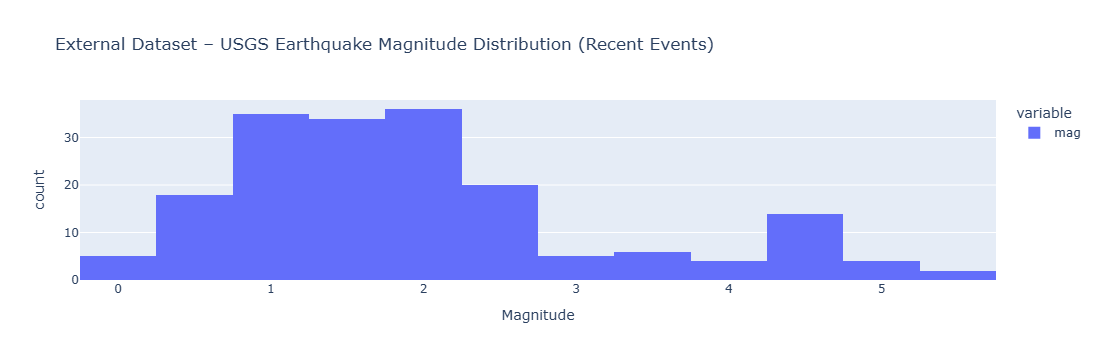

In [66]:
import plotly.express as px

fig_usgs_mag = px.histogram(
    usgs_magnitudes,
    nbins=20,
    title="External Dataset – USGS Earthquake Magnitude Distribution (Recent Events)",
    labels={"value": "Magnitude"}
)

fig_usgs_mag.show()


## Interpretation - External Dataset (USGS)

To enrich the historical earthquake analysis based on the NOAA dataset, an external dataset from the United States Geological Survey (USGS) was used. This dataset contains recent earthquake events recorded in December 2022 and provides high-precision magnitude and location measurements.

The magnitude distribution of the USGS data shows that low- to moderate-magnitude earthquakes are significantly more frequent than high-magnitude events. This pattern is consistent with the magnitude trends observed in the historical NOAA dataset, where smaller earthquakes occur much more often than large, destructive ones.

By comparing recent USGS observations with long-term historical data, this external dataset validates the reliability of the magnitude-based indicators and confirms that the fundamental characteristics of earthquake occurrence remain stable over time. The USGS dataset therefore strengthens the interpretation of the historical analysis by providing a contemporary reference point.

In [69]:
def create_dashboard(fig_century, fig_magnitude, fig_temporal, fig_spatial, fig_usgs):
    """
    Creates a Dash dashboard with four internal indicators
    and one external USGS indicator.
    """

    app = dash.Dash(__name__)

    app.layout = html.Div(children=[

        html.H1("Earthquake Data Analysis Dashboard"),

        html.P(
            "Objective: Visualize key indicators extracted from the NOAA earthquake dataset "
            "and validate results using an external USGS dataset."
        ),

        html.P("Dataset: NOAA Earthquake Dataset"),
        html.P("External Dataset: USGS Earthquake Dataset"),
        html.P("Team Leader: Alfred Abishek ANTHONY CRUZ"),
        html.P("Team Members: Alfred, Govinda, Norbert, Venkat Sai, Samyuktha, Ankit"),

        dcc.Graph(figure=fig_century),
        dcc.Graph(figure=fig_magnitude),
        dcc.Graph(figure=fig_temporal),
        dcc.Graph(figure=fig_spatial),
        dcc.Graph(figure=fig_usgs)

    ])

    return app


In [70]:
if __name__ == "__main__":

    # Create figures
    fig5 = fig_usgs_mag
    
app = create_dashboard(fig1, fig2, fig3, fig4, fig5)
app.run(debug=True, port=8051)


### Dashboard Summary

The dashboard integrates four analytical indicators derived from the NOAA earthquake dataset,
including statistical, temporal, and spatial analyses. An additional indicator based on recent
USGS earthquake data is included to validate historical magnitude patterns and enhance the
interpretation of results. The dashboard enables an interactive exploration of earthquake
behavior across time and geographic regions.
